In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Data loaded and split successfully.")

Data loaded and split successfully.


In [3]:
# Apply feature scaling using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Feature scaling applied.")

Feature scaling applied.


In [4]:
# Take user input for the value of K
k_value = int(input("Enter the value of K: "))

# Train KNN classifier
knn_model = KNeighborsClassifier(n_neighbors=k_value)
knn_model.fit(X_train_scaled, y_train)
print(f"KNN Classifier trained with K={k_value}.")

KNN Classifier trained with K=3.


In [5]:
# Take user input for flower features
print("Enter flower features for prediction:")
sepal_length = float(input("Sepal Length: "))
sepal_width = float(input("Sepal Width: "))
petal_length = float(input("Petal Length: "))
petal_width = float(input("Petal Width: "))

# Prepare the input and scale it
user_input = np.array([[sepal_length, sepal_width, petal_length, petal_width]])
user_input_scaled = scaler.transform(user_input)

# Predict the class
predicted_class_idx = knn_model.predict(user_input_scaled)[0]
predicted_species = iris.target_names[predicted_class_idx]

print(f"\n--- Prediction ---")
print(f"Predicted Class Index: {predicted_class_idx}")
print(f"Predicted Species: {predicted_species.capitalize()}")

Enter flower features for prediction:

--- Prediction ---
Predicted Class Index: 1
Predicted Species: Versicolor


Accuracy Score: 100.00%



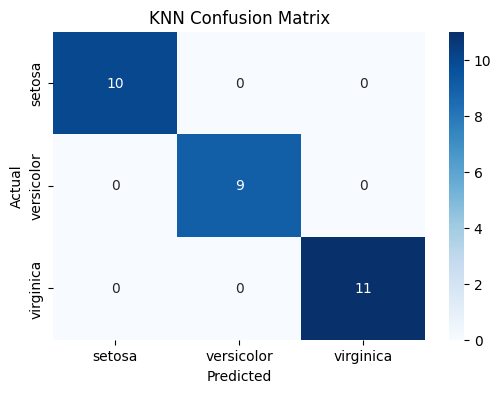

In [6]:
# Predict on the test set
y_pred = knn_model.predict(X_test_scaled)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy * 100:.2f}%\n")

# Generate and display the confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d",
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('KNN Confusion Matrix')
plt.show()